In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_pure   # NON-timemax, NON-phasemax
import parismc
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10     # Time step
T = 12/12     # Total time

print(f"Using dt = {dt} seconds, T = {T} years")

inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0,
        "include_minus_m": False,
}

amplitude_kwargs = {
    "force_backend": force_backend
}

Ylm_kwargs = {
    "force_backend": force_backend,
}

sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1,6)
ell = 2

loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None
)

print('Done initializing loglike class.')

data     = loglike_obj.signal
data_snr = float(gwf.rhostat(data))
print('SNR:', data_snr)


Using dt = 10 seconds, T = 1.0 years
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
SNR: 14.0812757390131


In [2]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    # hypercube 3sigma bounds
    logm1lim = [5.98048, 6.03302]
    logm2lim = [0.98948, 1.01795]
    alim = [0.65790, 0.76934]
    p0lim = [8.60482, 9.24008]
    e0lim = [0.38645, 0.40777]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

print('Done setting up log-likelihood and prior.')

Done setting up log-likelihood and prior.


In [3]:
dir_scratch='/scratch/e1498138'

filepath=f'{dir_scratch}/paris3/int_3mth_snr32_1/sampler_state.pkl'


In [4]:
filepath

'/scratch/e1498138/paris3/int_3mth_snr32_1/sampler_state.pkl'

In [6]:
sampler = parismc.Sampler.load_state(filepath)

In [7]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.388079  , 0.37659544, 0.39539405, 0.60478694, 0.62463344],
        [0.3880887 , 0.37657882, 0.3953991 , 0.60479307, 0.62463048],
        [0.38808601, 0.37659082, 0.39540816, 0.60480117, 0.62462458],
        ...,
        [0.406351  , 0.39443622, 0.41237626, 0.5872693 , 0.60539363],
        [0.45191283, 0.42319015, 0.4584191 , 0.54101223, 0.56980992],
        [0.45623925, 0.41233723, 0.46491442, 0.53389616, 0.57679884]],
       shape=(20000, 5)),
 array([[ 0.462857  ,  0.41259109,  0.47408643,  0.52612177,  0.57759259],
        [ 0.46287919,  0.4126015 ,  0.4740947 ,  0.52612728,  0.57759189],
        [ 0.46287779,  0.41260829,  0.47410722,  0.52612877,  0.57759333],
        ...,
        [-0.05041358,  1.12516334,  0.62971164,  0.67234353,  1.45664458],
        [ 0.87629202,  0.3311047 ,  0.48063698,  0.83592321,  1.3948192 ],
        [ 0.52347162,  0.50489381,  0.87419152,  0.39756759,  0.54156514]],
       shape=(20000, 5))]

In [8]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 1.70773705,  0.01576363,  0.00958974, ...,  0.24369851,
         2.4951501 , -0.01662802], shape=(20000,)),
 array([ 1.62256948e+00,  3.98678064e-02,  3.67726522e-02, ...,
                   -inf,            -inf, -1.04466828e-04], shape=(20000,))]

In [9]:
int(np.argmax(sampler.max_logden_list))


0

In [10]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list[0])].reshape(1, -1))
maxld_pt1

array([[6.0008168 , 1.00026088, 0.70176435, 8.98987404, 0.39974907]])

In [11]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list[1])].reshape(1, -1))
maxld_pt2

array([[6.00482808, 1.00123463, 0.71064264, 8.9388329 , 0.39872015]])

In [12]:
log_density([param_true])

array([13.93466256])

In [13]:
log_density(maxld_pt1), log_density(maxld_pt2)

(array([13.88779459]), array([9.6270631]))

In [14]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [15]:
gwf.rhostat(h_pt1), gwf.Xstat(data, data), gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(14.0910379), array(14.08127574), array(14.02051384), array(14.00518577))

In [16]:
param_ranges = [(5.98048, 6.03302),
                (0.98948, 1.01795),
                (0.65790, 0.76934),
                (8.60482, 9.24008),
                (0.38645, 0.40777)
                ]
param_ranges

[(5.98048, 6.03302),
 (0.98948, 1.01795),
 (0.6579, 0.76934),
 (8.60482, 9.24008),
 (0.38645, 0.40777)]

In [17]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

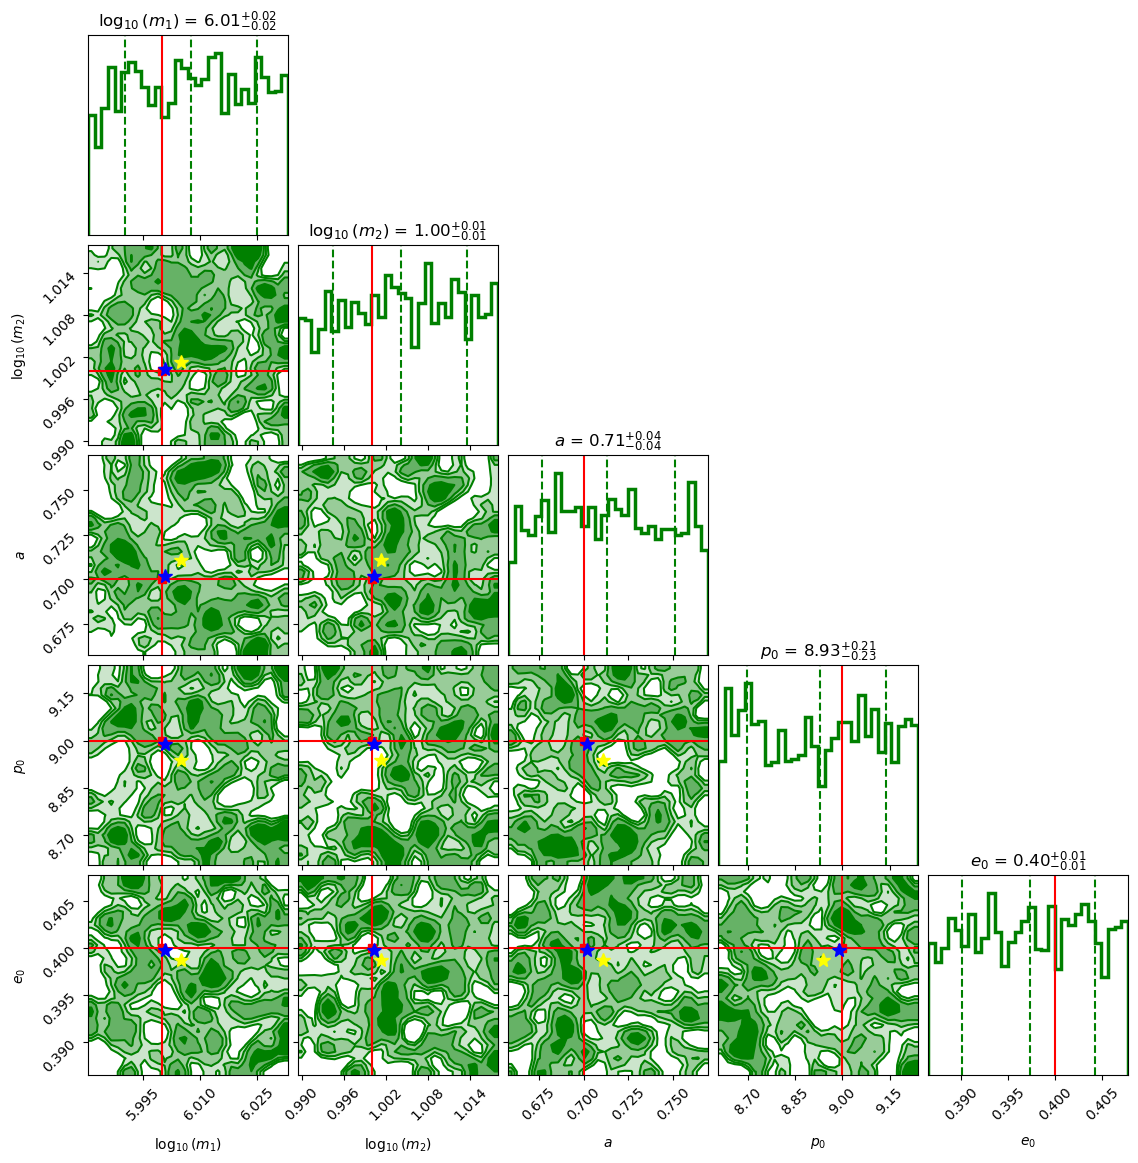

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='yellow', marker='*', ms=10, 
                       reverse=False)

# connection proc 1

In [19]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.0008168 , 1.00026088, 0.70176435, 8.98987404, 0.39974907]])

In [20]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [21]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [22]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


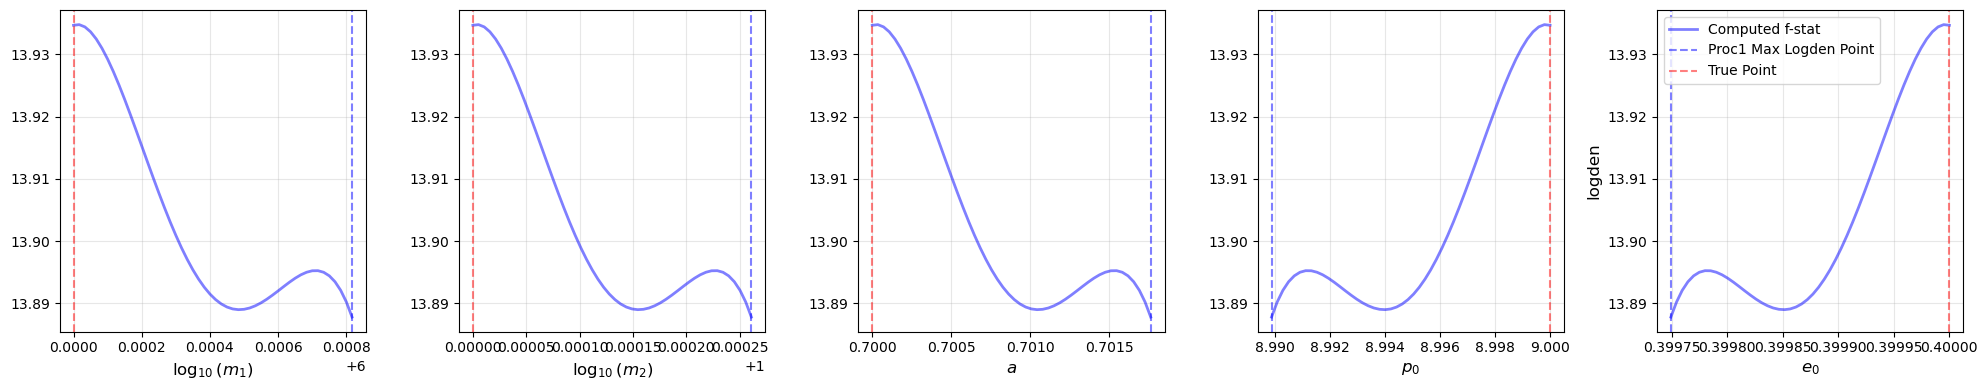

In [23]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


# proc 2

In [24]:
proc2_maxld_pt = maxld_pt2.copy()
proc2_maxld_pt

array([[6.00482808, 1.00123463, 0.71064264, 8.9388329 , 0.39872015]])

In [25]:
# connect two highest logden pts

proc2_maxld_pt_1d = proc2_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
line_points_proc2 = proc2_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc2_maxld_pt_1d)[:, np.newaxis]


In [26]:
logden_theory_proc2 = []
logden_theory_proc2.append(log_density(np.array(line_points_proc2).T))


In [27]:
logden_theory_proc2 = np.array(logden_theory_proc2).flatten()


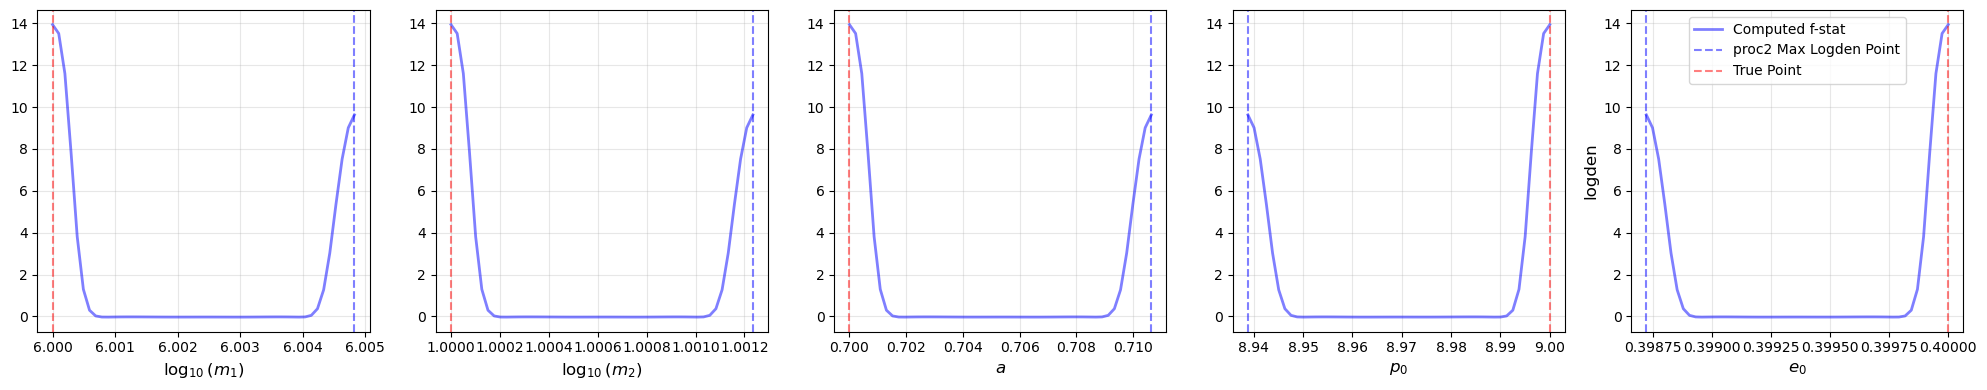

In [28]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc2[dim], logden_theory_proc2, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc2_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'proc2 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
